<a href="https://colab.research.google.com/github/ahamedcader8055-gtr/NorthStar-Analytics/blob/main/NorthStar_Part3_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Installed required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# Load all 10 CSV files
customers   = pd.read_csv('/content/customers.csv')
complaints  = pd.read_csv('/content/complaints.csv')
app_events  = pd.read_csv('/content/app_events.csv')
deliveries  = pd.read_csv('/content/deliveries.csv')
drivers     = pd.read_csv('/content/drivers.csv')
hubs        = pd.read_csv('/content/hubs.csv')
incidents   = pd.read_csv('/content/incidents.csv')
orders      = pd.read_csv('/content/orders.csv')
vehicles    = pd.read_csv('/content/vehicles.csv')
data_dict   = pd.read_csv('/content/data_dictionary.csv')

# Confirm all files loaded
print("All 10 files loaded successfully!")
print(f"Orders: {len(orders)} rows")
print(f"Deliveries: {len(deliveries)} rows")
print(f"Customers: {len(customers)} rows")
print(f"Complaints: {len(complaints)} rows")
print(f"Drivers: {len(drivers)} rows")
print(f"Vehicles: {len(vehicles)} rows")
print(f"Incidents: {len(incidents)} rows")
print(f"App Events: {len(app_events)} rows")
print(f"Hubs: {len(hubs)} rows")
print(f"Data Dictionary: {len(data_dict)} rows")

All 10 files loaded successfully!
Orders: 1250 rows
Deliveries: 950 rows
Customers: 650 rows
Complaints: 320 rows
Drivers: 170 rows
Vehicles: 120 rows
Incidents: 280 rows
App Events: 640 rows
Hubs: 8 rows
Data Dictionary: 9 rows


In [3]:
#Data Quality Checks across all datasets

print("=" * 60)
print("DATA QUALITY REPORT — NorthStar Analytics")
print("=" * 60)

# Check missing values in each dataset
datasets = {
    'customers':  customers,
    'complaints':  complaints,
    'app_events':  app_events,
    'deliveries':  deliveries,
    'drivers':     drivers,
    'hubs':        hubs,
    'incidents':   incidents,
    'orders':      orders,
    'vehicles':    vehicles
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"\n{name.upper()} — {len(df)} rows, {len(df.columns)} columns")
    if len(missing) > 0:
        print("  Missing values:")
        for col, count in missing.items():
            pct = round(count / len(df) * 100, 2)
            print(f"    {col}: {count} missing ({pct}%)")
    else:
        print("  No missing values found")

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    print(f"  {name}: {dupes} duplicate rows")

print("\n" + "=" * 60)
print("DATA TYPE CHECK")
print("=" * 60)
for name, df in datasets.items():
    print(f"\n{name.upper()}:")
    print(df.dtypes)

DATA QUALITY REPORT — NorthStar Analytics

CUSTOMERS — 650 rows, 9 columns
  Missing values:
    loyalty_score: 20 missing (3.08%)
    preferred_channel: 13 missing (2.0%)

COMPLAINTS — 320 rows, 10 columns
  Missing values:
    compensation_amount: 16 missing (5.0%)

APP_EVENTS — 640 rows, 10 columns
  Missing values:
    order_id: 144 missing (22.5%)

DELIVERIES — 950 rows, 13 columns
  Missing values:
    delivery_completed_at: 19 missing (2.0%)
    customer_rating_post_delivery: 14 missing (1.47%)

DRIVERS — 170 rows, 8 columns
  Missing values:
    training_score: 7 missing (4.12%)

HUBS — 8 rows, 5 columns
  No missing values found

INCIDENTS — 280 rows, 7 columns
  Missing values:
    resolved_hours: 17 missing (6.07%)

ORDERS — 1250 rows, 11 columns
  Missing values:
    booking_channel: 25 missing (2.0%)

VEHICLES — 120 rows, 8 columns
  Missing values:
    battery_health_pct: 4 missing (3.33%)

DUPLICATE CHECK
  customers: 0 duplicate rows
  complaints: 0 duplicate rows
  app

In [5]:
#Fix all data quality issues

print("=" * 60)
print("FIXING DATA QUALITY ISSUES")
print("=" * 60)

#Fix date columns
print("\n1. Converting date columns to datetime format...")

customers['signup_date']              = pd.to_datetime(customers['signup_date'],   errors='coerce')
complaints['created_at']              = pd.to_datetime(complaints['created_at'],   errors='coerce')
app_events['event_timestamp']         = pd.to_datetime(app_events['event_timestamp'], errors='coerce')
deliveries['dispatch_time']           = pd.to_datetime(deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at']   = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
incidents['reported_at']              = pd.to_datetime(incidents['reported_at'],   errors='coerce')
orders['order_created_at']            = pd.to_datetime(orders['order_created_at'], errors='coerce')
vehicles['commission_date']           = pd.to_datetime(vehicles['commission_date'], errors='coerce')

print("   Date columns converted successfully!")

#Fix inconsistent zone names
print("\n2. Standardising zone names to title case...")

customers['home_zone']    = customers['home_zone'].str.strip().str.title()
orders['pickup_zone']     = orders['pickup_zone'].str.strip().str.title()
orders['dropoff_zone']    = orders['dropoff_zone'].str.strip().str.title()
drivers['base_zone']      = drivers['base_zone'].str.strip().str.title()
vehicles['assigned_zone'] = vehicles['assigned_zone'].str.strip().str.title()
app_events['zone_context']= app_events['zone_context'].str.strip().str.title()
hubs['zone']              = hubs['zone'].str.strip().str.title()

print("   Zone names standardised successfully!")

#Fix missing values
print("\n3. Handling missing values...")

#Fill missing loyalty score with median
customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)
print(f"   customers.loyalty_score: filled with median ({customers['loyalty_score'].median():.2f})")

#Fill missing preferred channel with mode
customers['preferred_channel'].fillna(customers['preferred_channel'].mode()[0], inplace=True)
print(f"   customers.preferred_channel: filled with mode ({customers['preferred_channel'].mode()[0]})")

#Fill missing compensation amount with median
complaints['compensation_amount'].fillna(complaints['compensation_amount'].median(), inplace=True)
print(f"   complaints.compensation_amount: filled with median ({complaints['compensation_amount'].median():.2f})")

#Fill missing training score with median
drivers['training_score'].fillna(drivers['training_score'].median(), inplace=True)
print(f"   drivers.training_score: filled with median ({drivers['training_score'].median():.2f})")

#Fill missing battery health with median
vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median(), inplace=True)
print(f"   vehicles.battery_health_pct: filled with median ({vehicles['battery_health_pct'].median():.2f})")

#Fill missing resolved hours with median
incidents['resolved_hours'].fillna(incidents['resolved_hours'].median(), inplace=True)
print(f"   incidents.resolved_hours: filled with median ({incidents['resolved_hours'].median():.2f})")

#Fill missing booking channel with Unknown
orders['booking_channel'].fillna('Unknown', inplace=True)
print(f"   orders.booking_channel: filled with 'Unknown'")

#app_events order_id — keep as NaN (legitimate missing — session not linked to order)
print(f"   app_events.order_id: kept as NaN (legitimate — session not linked to order)")

#Verify fixes
print("\n4. Verifying fixes...")
total_missing = 0
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    total_missing += missing
    if missing > 0:
        print(f"   {name}: {missing} missing values remaining")

if total_missing == 0:
    print("   All missing values resolved!")
else:
    print(f"   Total remaining missing values: {total_missing}")

print("\n" + "=" * 60)
print("DATA CLEANING COMPLETE!")
print("=" * 60)

FIXING DATA QUALITY ISSUES

1. Converting date columns to datetime format...
   Date columns converted successfully!

2. Standardising zone names to title case...
   Zone names standardised successfully!

3. Handling missing values...
   customers.loyalty_score: filled with median (59.60)
   customers.preferred_channel: filled with mode (App)
   complaints.compensation_amount: filled with median (18.41)
   drivers.training_score: filled with median (75.20)
   vehicles.battery_health_pct: filled with median (78.05)
   incidents.resolved_hours: filled with median (11.50)
   orders.booking_channel: filled with 'Unknown'
   app_events.order_id: kept as NaN (legitimate — session not linked to order)

4. Verifying fixes...
   app_events: 144 missing values remaining
   deliveries: 33 missing values remaining
   Total remaining missing values: 177

DATA CLEANING COMPLETE!


ZONE STANDARDISATION VERIFICATION

Unique zones after standardisation:

customers.home_zone:    ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']

orders.pickup_zone:     ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']

orders.dropoff_zone:    ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']

drivers.base_zone:      ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']

vehicles.assigned_zone: ['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']

app_events.zone_context:['Airport', 'Central', 'Ctr', 'East', 'North', 'Riverside', 'South', 'West']

hubs.zone:              ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

ORDER VOLUME BY ZONE AFTER STANDARDISATION
        zone  total_orders
0       East           207
1      South           181
2      North           174
3    Central           158
4       West           155
5  Riverside    

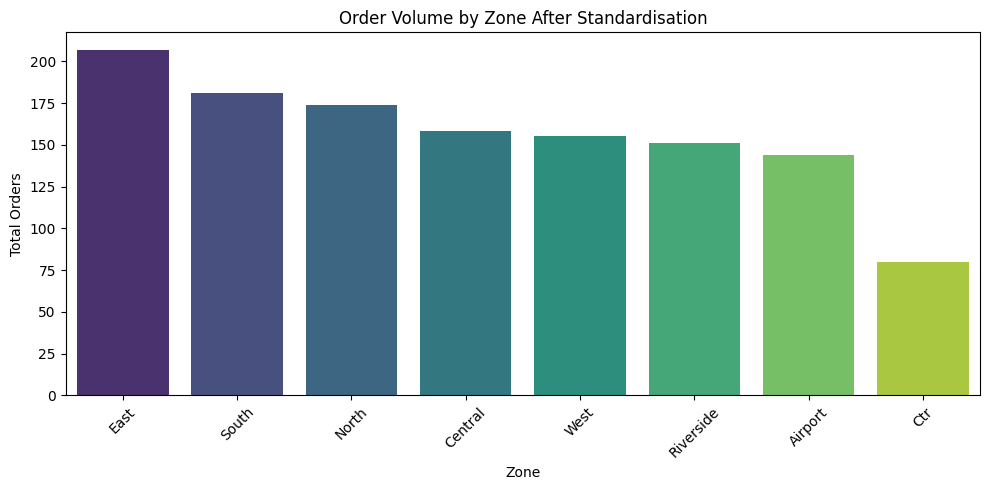

In [6]:
#Verify zone standardisation and show before/after

print("=" * 60)
print("ZONE STANDARDISATION VERIFICATION")
print("=" * 60)

#Check unique zones in each dataset after cleaning
print("\nUnique zones after standardisation:")
print(f"\ncustomers.home_zone:    {sorted(customers['home_zone'].unique())}")
print(f"\norders.pickup_zone:     {sorted(orders['pickup_zone'].unique())}")
print(f"\norders.dropoff_zone:    {sorted(orders['dropoff_zone'].unique())}")
print(f"\ndrivers.base_zone:      {sorted(drivers['base_zone'].unique())}")
print(f"\nvehicles.assigned_zone: {sorted(vehicles['assigned_zone'].unique())}")
print(f"\napp_events.zone_context:{sorted(app_events['zone_context'].unique())}")
print(f"\nhubs.zone:              {sorted(hubs['zone'].unique())}")

#Count zone frequencies in orders
print("\n" + "=" * 60)
print("ORDER VOLUME BY ZONE AFTER STANDARDISATION")
print("=" * 60)
zone_counts = orders['pickup_zone'].value_counts().reset_index()
zone_counts.columns = ['zone', 'total_orders']
print(zone_counts)

#Visualise
plt.figure(figsize=(10, 5))
sns.barplot(data=zone_counts, x='zone', y='total_orders', palette='viridis')
plt.title('Order Volume by Zone After Standardisation')
plt.xlabel('Zone')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FIXING CTR ZONE — MERGING WITH CENTRAL
  customers.home_zone: replaced 33 'Ctr' values with 'Central'
  orders_pickup.pickup_zone: replaced 80 'Ctr' values with 'Central'
  orders_dropoff.dropoff_zone: replaced 58 'Ctr' values with 'Central'
  drivers.base_zone: replaced 6 'Ctr' values with 'Central'
  vehicles.assigned_zone: replaced 6 'Ctr' values with 'Central'
  app_events.zone_context: replaced 43 'Ctr' values with 'Central'

Verifying fix...
  orders.pickup_zone unique values: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  customers.home_zone unique values: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

Updated order volume by zone:
        zone  total_orders
0    Central           238
1       East           207
2      South           181
3      North           174
4       West           155
5  Riverside           151
6    Airport           144


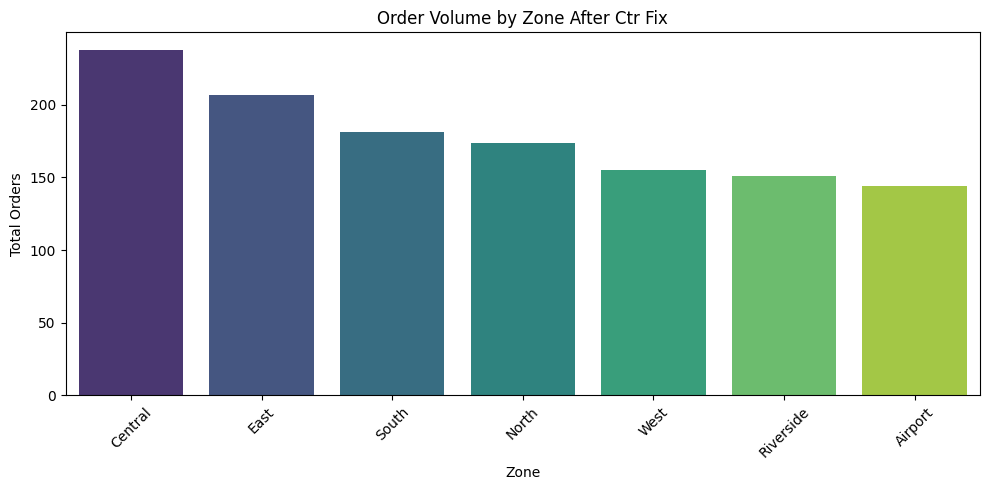


Ctr zone fix complete!


In [7]:
#Fixing Ctr zone — merge with Central

print("=" * 60)
print("FIXING CTR ZONE — MERGING WITH CENTRAL")
print("=" * 60)

#Replace 'Ctr' with 'Central' across all datasets
datasets_to_fix = {
    'customers':  ('home_zone',     customers),
    'orders_pickup': ('pickup_zone',  orders),
    'orders_dropoff': ('dropoff_zone', orders),
    'drivers':    ('base_zone',     drivers),
    'vehicles':   ('assigned_zone', vehicles),
    'app_events': ('zone_context',  app_events)
}

for name, (col, df) in datasets_to_fix.items():
    before = df[col].value_counts().get('Ctr', 0)
    df[col] = df[col].replace('Ctr', 'Central')
    after  = df[col].value_counts().get('Ctr', 0)
    print(f"  {name}.{col}: replaced {before} 'Ctr' values with 'Central'")

#Verify fix
print("\nVerifying fix...")
print(f"  orders.pickup_zone unique values: {sorted(orders['pickup_zone'].unique())}")
print(f"  customers.home_zone unique values: {sorted(customers['home_zone'].unique())}")

#Show updated zone counts
print("\nUpdated order volume by zone:")
zone_counts_fixed = orders['pickup_zone'].value_counts().reset_index()
zone_counts_fixed.columns = ['zone', 'total_orders']
print(zone_counts_fixed)

#Visualise updated zone distribution
plt.figure(figsize=(10, 5))
sns.barplot(data=zone_counts_fixed, x='zone',
            y='total_orders', palette='viridis')
plt.title('Order Volume by Zone After Ctr Fix')
plt.xlabel('Zone')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nCtr zone fix complete!")

In [8]:
#Reshape and merge datasets for analysis

print("=" * 60)
print("RESHAPING AND MERGING DATASETS")
print("=" * 60)

#Master delivery dataset
print("\n1. Creating master delivery dataset...")
master_delivery = deliveries.merge(orders,    on='order_id',   how='left') \
                             .merge(drivers,   on='driver_id',  how='left') \
                             .merge(vehicles,  on='vehicle_id', how='left') \
                             .merge(hubs,      on='hub_id',     how='left')

print(f"   Master delivery dataset: {len(master_delivery)} rows, {len(master_delivery.columns)} columns")
print(f"   Columns: {list(master_delivery.columns)}")

#Master customer dataset
print("\n2. Creating master customer dataset...")
master_customer = customers.merge(
    complaints.groupby('customer_id').agg(
        total_complaints    = ('complaint_id', 'count'),
        avg_compensation    = ('compensation_amount', 'mean'),
        avg_resolution_days = ('resolution_days', 'mean'),
        escalated_complaints= ('status', lambda x: (x=='Escalated').sum())
    ).reset_index(),
    on='customer_id', how='left'
)
master_customer['total_complaints']     = master_customer['total_complaints'].fillna(0)
master_customer['avg_compensation']     = master_customer['avg_compensation'].fillna(0)
master_customer['avg_resolution_days']  = master_customer['avg_resolution_days'].fillna(0)
master_customer['escalated_complaints'] = master_customer['escalated_complaints'].fillna(0)

print(f"   Master customer dataset: {len(master_customer)} rows, {len(master_customer.columns)} columns")

#Master incident dataset
print("\n3. Creating master incident dataset...")
master_incident = incidents.merge(deliveries, on='delivery_id', how='left') \
                            .merge(vehicles,  on='vehicle_id',  how='left') \
                            .merge(drivers,   on='driver_id',   how='left')

print(f"   Master incident dataset: {len(master_incident)} rows, {len(master_incident.columns)} columns")

#Add calculated columns to master delivery
print("\n4. Adding calculated columns...")

#Delivery duration in hours
master_delivery['delivery_duration_hours'] = (
    master_delivery['delivery_completed_at'] -
    master_delivery['dispatch_time']
).dt.total_seconds() / 3600

#Is failed flag
master_delivery['is_failed']  = (master_delivery['delivery_status'] == 'Failed').astype(int)
master_delivery['is_delayed'] = (master_delivery['delivery_status'] == 'Delayed').astype(int)
master_delivery['is_ontime']  = (master_delivery['delivery_status'] == 'OnTime').astype(int)

#Month year for trend analysis
master_delivery['month_year'] = master_delivery['dispatch_time'].dt.to_period('M').astype(str)

print(f"   Calculated columns added successfully!")
print(f"   Final master delivery columns: {list(master_delivery.columns)}")

print("\n" + "=" * 60)
print("RESHAPING AND MERGING COMPLETE!")
print("=" * 60)

RESHAPING AND MERGING DATASETS

1. Creating master delivery dataset...
   Master delivery dataset: 950 rows, 41 columns
   Columns: ['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag', 'base_zone', 'employment_type', 'years_experience', 'training_score', 'driver_rating', 'shift_preference', 'active_flag', 'vehicle_type', 'assigned_zone', 'commission_date', 'battery_health_pct', 'odometer_km', 'maintenance_status', 'telematics_version', 'hub_name', 'zone', 'hub_type', 'capacity_score']

2. Creating master customer dataset...
   Master customer dataset: 650 rows, 13 columns

3. Creating master incid

PROCESSING SEMI-STRUCTURED DATA

1. Processing app event sequences...
   Session summaries created: 637 sessions
   Sessions with failures: 38
   Sessions with chat escalation: 38
   Sessions with payment retry: 69
   Sessions with cancel attempt: 28

   Sample event sequences:
  session_id event_sequence  failed_events
0     S10192  payment_retry              0
1     S10325    eta_refresh              0
2     S10481    eta_refresh              0
3     S10509    eta_refresh              0
4     S10635   search_route              0

2. Processing incident data...
   Vehicle incident profiles created: 109 vehicles
   Vehicles with critical incidents: 26
   Vehicles with unresolved incidents: 60

   Top 5 vehicles by incident count:
   vehicle_id  total_incidents  critical_incidents  unresolved_incidents  avg_resolve_hours
42       V047                9                   1                     2          10.966667
96       V108                7                   1                     2    

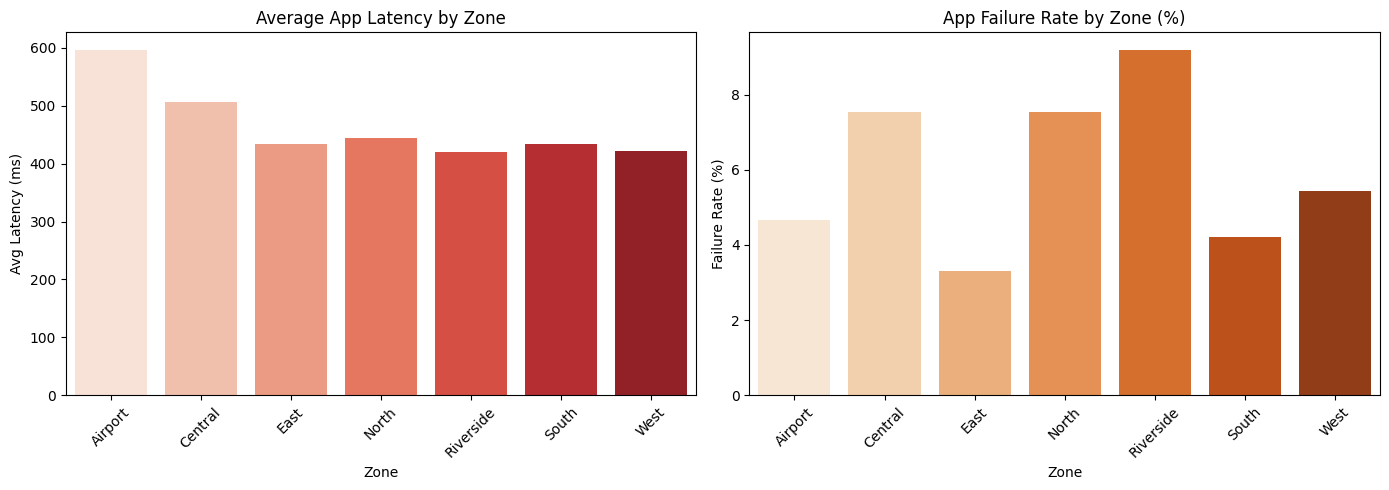


SEMI-STRUCTURED DATA PROCESSING COMPLETE!


In [9]:
#Processing semi-structured app events and incident data

print("=" * 60)
print("PROCESSING SEMI-STRUCTURED DATA")
print("=" * 60)

#Process app events — create session summaries
print("\n1. Processing app event sequences...")

session_summary = app_events.groupby('session_id').agg(
    customer_id        = ('customer_id', 'first'),
    order_id           = ('order_id', 'first'),
    zone               = ('zone_context', 'first'),
    device_type        = ('device_type', 'first'),
    session_start      = ('event_timestamp', 'min'),
    session_end        = ('event_timestamp', 'max'),
    total_events       = ('event_id', 'count'),
    failed_events      = ('success_flag', lambda x: (x==0).sum()),
    avg_latency_ms     = ('api_latency_ms', 'mean'),
    max_latency_ms     = ('api_latency_ms', 'max'),
    event_sequence     = ('event_type', lambda x: ' -> '.join(x.tolist())),
    had_chat_escalation= ('event_type', lambda x: ('chat_escalated' in x.values)),
    had_payment_retry  = ('event_type', lambda x: ('payment_retry' in x.values)),
    had_cancel_attempt = ('event_type', lambda x: ('cancel_attempt' in x.values))
).reset_index()

#Calculate session duration in minutes
session_summary['session_duration_mins'] = (
    session_summary['session_end'] -
    session_summary['session_start']
).dt.total_seconds() / 60

#Calculate failure rate per session
session_summary['failure_rate'] = (
    session_summary['failed_events'] /
    session_summary['total_events'] * 100
).round(2)

print(f"   Session summaries created: {len(session_summary)} sessions")
print(f"   Sessions with failures: {(session_summary['failed_events']>0).sum()}")
print(f"   Sessions with chat escalation: {session_summary['had_chat_escalation'].sum()}")
print(f"   Sessions with payment retry: {session_summary['had_payment_retry'].sum()}")
print(f"   Sessions with cancel attempt: {session_summary['had_cancel_attempt'].sum()}")
print(f"\n   Sample event sequences:")
print(session_summary[['session_id','event_sequence','failed_events']].head(5).to_string())

#Process incidents — create vehicle incident profiles
print("\n2. Processing incident data...")

vehicle_incident_profile = incidents.merge(
    deliveries[['delivery_id','vehicle_id','driver_id','hub_id']],
    on='delivery_id', how='left'
).groupby('vehicle_id').agg(
    total_incidents      = ('incident_id', 'count'),
    critical_incidents   = ('severity', lambda x: (x=='Critical').sum()),
    high_incidents       = ('severity', lambda x: (x=='High').sum()),
    unresolved_incidents = ('resolution_status', lambda x: (x=='Open').sum()),
    escalated_incidents  = ('resolution_status', lambda x: (x=='Escalated').sum()),
    avg_resolve_hours    = ('resolved_hours', 'mean'),
    max_resolve_hours    = ('resolved_hours', 'max'),
    incident_types       = ('incident_type', lambda x: ', '.join(x.unique().tolist())),
    battery_alerts       = ('incident_type', lambda x: (x=='BatteryAlert').sum()),
    vehicle_faults       = ('incident_type', lambda x: (x=='VehicleFault').sum())
).reset_index()

print(f"   Vehicle incident profiles created: {len(vehicle_incident_profile)} vehicles")
print(f"   Vehicles with critical incidents: {(vehicle_incident_profile['critical_incidents']>0).sum()}")
print(f"   Vehicles with unresolved incidents: {(vehicle_incident_profile['unresolved_incidents']>0).sum()}")
print(f"\n   Top 5 vehicles by incident count:")
print(vehicle_incident_profile.nlargest(5, 'total_incidents')[
    ['vehicle_id','total_incidents','critical_incidents',
     'unresolved_incidents','avg_resolve_hours']
].to_string())

#Visualise session failure rates by zone
print("\n3. Visualising app session failures by zone...")

zone_session = session_summary.groupby('zone').agg(
    total_sessions  = ('session_id', 'count'),
    avg_latency     = ('avg_latency_ms', 'mean'),
    failure_rate    = ('failure_rate', 'mean'),
    escalations     = ('had_chat_escalation', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=zone_session, x='zone', y='avg_latency',
            palette='Reds', ax=axes[0])
axes[0].set_title('Average App Latency by Zone')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Avg Latency (ms)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=zone_session, x='zone', y='failure_rate',
            palette='Oranges', ax=axes[1])
axes[1].set_title('App Failure Rate by Zone (%)')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SEMI-STRUCTURED DATA PROCESSING COMPLETE!")
print("=" * 60)

In [10]:
#Prepare MongoDB-ready JSON documents

print("=" * 60)
print("PREPARING MONGODB DOCUMENTS")
print("=" * 60)

#Customer documents with embedded complaints and app events
print("\n1. Creating customer documents...")

mongo_customers = []

for _, customer in customers.iterrows():
    #Get complaints for this customer
    cust_complaints = complaints[
        complaints['customer_id'] == customer['customer_id']
    ].copy()

    #Get app events for this customer
    cust_events = app_events[
        app_events['customer_id'] == customer['customer_id']
    ].copy()

    #Get orders for this customer
    cust_orders = orders[
        orders['customer_id'] == customer['customer_id']
    ].copy()

    #Build complaint list
    complaint_list = []
    for _, complaint in cust_complaints.iterrows():
        complaint_list.append({
            'complaint_id':      complaint['complaint_id'],
            'order_id':          complaint['order_id'],
            'complaint_type':    complaint['complaint_type'],
            'channel':           complaint['channel'],
            'severity':          complaint['severity'],
            'created_at':        str(complaint['created_at']),
            'status':            complaint['status'],
            'resolution_days':   int(complaint['resolution_days']),
            'compensation_amount': float(complaint['compensation_amount'])
        })

    #Build app event list
    event_list = []
    for _, event in cust_events.iterrows():
        event_list.append({
            'event_id':       event['event_id'],
            'order_id':       str(event['order_id']) if pd.notna(event['order_id']) else None,
            'event_timestamp':str(event['event_timestamp']),
            'event_type':     event['event_type'],
            'session_id':     event['session_id'],
            'device_type':    event['device_type'],
            'zone_context':   event['zone_context'],
            'api_latency_ms': int(event['api_latency_ms']),
            'success_flag':   int(event['success_flag'])
        })

    #Build order list
    order_list = []
    for _, order in cust_orders.iterrows():
        order_list.append({
            'order_id':             order['order_id'],
            'service_type':         order['service_type'],
            'order_created_at':     str(order['order_created_at']),
            'promised_window_hours':int(order['promised_window_hours']),
            'pickup_zone':          order['pickup_zone'],
            'dropoff_zone':         order['dropoff_zone'],
            'priority_level':       order['priority_level'],
            'order_value':          float(order['order_value']),
            'booking_channel':      order['booking_channel'],
            'special_handling_flag':int(order['special_handling_flag'])
        })

    #Build customer document
    customer_doc = {
        '_id':                  customer['customer_id'],
        'customer_id':          customer['customer_id'],
        'age':                  int(customer['age']),
        'home_zone':            customer['home_zone'],
        'customer_type':        customer['customer_type'],
        'signup_date':          str(customer['signup_date']),
        'loyalty_score':        float(customer['loyalty_score']),
        'app_engagement_score': float(customer['app_engagement_score']),
        'preferred_channel':    customer['preferred_channel'],
        'account_status':       customer['account_status'],
        'complaints':           complaint_list,
        'app_events':           event_list,
        'orders':               order_list,
        'summary': {
            'total_complaints':  len(complaint_list),
            'total_app_events':  len(event_list),
            'total_orders':      len(order_list),
            'has_escalation':    any(c['status'] == 'Escalated' for c in complaint_list)
        }
    }
    mongo_customers.append(customer_doc)

print(f"   Customer documents created: {len(mongo_customers)}")
print(f"\n   Sample customer document:")
print(json.dumps(mongo_customers[0], indent=2, default=str)[:1000])

#Delivery documents with embedded incidents
print("\n2. Creating delivery documents...")

mongo_deliveries = []

for _, delivery in deliveries.iterrows():
    #Get incidents for this delivery
    deliv_incidents = incidents[
        incidents['delivery_id'] == delivery['delivery_id']
    ].copy()

    #Build incident list
    incident_list = []
    for _, incident in deliv_incidents.iterrows():
        incident_list.append({
            'incident_id':       incident['incident_id'],
            'incident_type':     incident['incident_type'],
            'reported_at':       str(incident['reported_at']),
            'severity':          incident['severity'],
            'resolution_status': incident['resolution_status'],
            'resolved_hours':    float(incident['resolved_hours'])
                                 if pd.notna(incident['resolved_hours']) else None
        })

    #Build delivery document
    delivery_doc = {
        '_id':                          delivery['delivery_id'],
        'delivery_id':                  delivery['delivery_id'],
        'order_id':                     delivery['order_id'],
        'driver_id':                    delivery['driver_id'],
        'vehicle_id':                   delivery['vehicle_id'],
        'hub_id':                       delivery['hub_id'],
        'dispatch_time':                str(delivery['dispatch_time']),
        'delivery_completed_at':        str(delivery['delivery_completed_at']),
        'delivery_status':              delivery['delivery_status'],
        'route_distance_km':            float(delivery['route_distance_km']),
        'manual_route_override_count':  int(delivery['manual_route_override_count']),
        'proof_of_completion_missing':  int(delivery['proof_of_completion_missing']),
        'customer_rating_post_delivery':float(delivery['customer_rating_post_delivery'])
                                        if pd.notna(delivery['customer_rating_post_delivery'])
                                        else None,
        'fuel_or_charge_cost':          float(delivery['fuel_or_charge_cost']),
        'incidents':                    incident_list,
        'summary': {
            'total_incidents':    len(incident_list),
            'has_critical':       any(i['severity'] == 'Critical' for i in incident_list),
            'has_unresolved':     any(i['resolution_status'] == 'Open' for i in incident_list)
        }
    }
    mongo_deliveries.append(delivery_doc)

print(f"   Delivery documents created: {len(mongo_deliveries)}")
print(f"\n   Sample delivery document:")
print(json.dumps(mongo_deliveries[0], indent=2, default=str)[:500])

#Save as JSON files
print("\n3. Saving MongoDB documents as JSON files...")

with open('/content/mongo_customers.json', 'w') as f:
    json.dump(mongo_customers, f, indent=2, default=str)

with open('/content/mongo_deliveries.json', 'w') as f:
    json.dump(mongo_deliveries, f, indent=2, default=str)

print(f"   mongo_customers.json saved — {len(mongo_customers)} documents")
print(f"   mongo_deliveries.json saved — {len(mongo_deliveries)} documents")

print("\n" + "=" * 60)
print("MONGODB DOCUMENTS PREPARED SUCCESSFULLY!")
print("=" * 60)

PREPARING MONGODB DOCUMENTS

1. Creating customer documents...
   Customer documents created: 650

   Sample customer document:
{
  "_id": "C0001",
  "customer_id": "C0001",
  "age": 26,
  "home_zone": "North",
  "customer_type": "SME",
  "signup_date": "2024-11-27 04:25:00",
  "loyalty_score": 44.9,
  "app_engagement_score": 69.2,
  "preferred_channel": "App",
  "account_status": "Active",
  "complaints": [
    {
      "complaint_id": "CP0096",
      "order_id": "O00007",
      "complaint_type": "AppIssue",
      "channel": "App",
      "severity": "High",
      "created_at": "2024-05-12 21:32:00",
      "status": "Resolved",
      "resolution_days": 22,
      "compensation_amount": 43.9
    },
    {
      "complaint_id": "CP0146",
      "order_id": "O00666",
      "complaint_type": "Delay",
      "channel": "Phone",
      "severity": "Medium",
      "created_at": "2025-09-01 20:17:00",
      "status": "Resolved",
      "resolution_days": 4,
      "compensation_amount": 0.0
    }
  ],

In [12]:
#Save all cleaned datasets and final outputs

print("=" * 60)
print("SAVING ALL CLEANED DATASETS")
print("=" * 60)

#Save cleaned datasets
customers.to_csv('/content/cleaned_customers.csv',   index=False)
complaints.to_csv('/content/cleaned_complaints.csv', index=False)
app_events.to_csv('/content/cleaned_app_events.csv', index=False)
deliveries.to_csv('/content/cleaned_deliveries.csv', index=False)
drivers.to_csv('/content/cleaned_drivers.csv',       index=False)
hubs.to_csv('/content/cleaned_hubs.csv',             index=False)
incidents.to_csv('/content/cleaned_incidents.csv',   index=False)
orders.to_csv('/content/cleaned_orders.csv',         index=False)
vehicles.to_csv('/content/cleaned_vehicles.csv',     index=False)

#Save master datasets
master_delivery.to_csv('/content/master_delivery.csv',   index=False)
master_customer.to_csv('/content/master_customer.csv',   index=False)
master_incident.to_csv('/content/master_incident.csv',   index=False)

#Save session summary
session_summary.to_csv('/content/session_summary.csv',           index=False)
vehicle_incident_profile.to_csv('/content/vehicle_incident_profile.csv', index=False)

print("Cleaned datasets saved:")
print("  cleaned_customers.csv")
print("  cleaned_complaints.csv")
print("  cleaned_app_events.csv")
print("  cleaned_deliveries.csv")
print("  cleaned_drivers.csv")
print("  cleaned_hubs.csv")
print("  cleaned_incidents.csv")
print("  cleaned_orders.csv")
print("  cleaned_vehicles.csv")

print("\nMaster datasets saved:")
print("  master_delivery.csv")
print("  master_customer.csv")
print("  master_incident.csv")

print("\nAnalytical datasets saved:")
print("  session_summary.csv")
print("  vehicle_incident_profile.csv")

print("\nMongoDB documents saved:")
print("  mongo_customers.json")
print("  mongo_deliveries.json")

print("\n" + "=" * 60)


SAVING ALL CLEANED DATASETS
Cleaned datasets saved:
  cleaned_customers.csv
  cleaned_complaints.csv
  cleaned_app_events.csv
  cleaned_deliveries.csv
  cleaned_drivers.csv
  cleaned_hubs.csv
  cleaned_incidents.csv
  cleaned_orders.csv
  cleaned_vehicles.csv

Master datasets saved:
  master_delivery.csv
  master_customer.csv
  master_incident.csv

Analytical datasets saved:
  session_summary.csv
  vehicle_incident_profile.csv

MongoDB documents saved:
  mongo_customers.json
  mongo_deliveries.json

